# Vectyfi Radar - V2 Honest Baseline
### Goal:
Build a mathematically bulletproof baseline model without target leakage.

**Key constraints addressed:**
1. Deduplication to solve the 1-to-n lot problem
2. Removal of complete CAN (Contract Award Notice) columns from the training set
3. Memory-efficient parsing of massive datasets\n

In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns # using plt_sns to avoid shadowing
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Apply dark theme
plt.style.use('dark_background')
print('✅ Libraries successfully loaded and ready for Vectyfi Radar V2 Baseline.')

✅ Libraries successfully loaded and ready for Vectyfi Radar V2 Baseline.


In [4]:
# Cell 2: Data Loading & Deduplication
file_path = '/Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv'

# Define columns to load to prevent OOM
CN_COLS = ['ID_NOTICE_CN', 'CPV', 'ISO_COUNTRY_CODE', 'B_FRA_AGREEMENT', 'TYPE_OF_CONTRACT']
TARGET_COLS = ['WIN_NAME', 'AWARD_VALUE_EURO']
CAN_COLS_TO_DROP = ['WIN_NAME', 'WIN_NATIONALID', 'WIN_ADDRESS', 'WIN_TOWN', 'WIN_POSTAL_CODE', 
                    'WIN_COUNTRY_CODE', 'B_AWARDED_TO_A_GROUP', 'B_CONTRACTOR_SME', 'NUMBER_OFFERS', 
                    'NUMBER_TENDERS_SME', 'NUMBER_TENDERS_OTHER_EU', 'NUMBER_TENDERS_NON_EU', 
                    'NUMBER_OFFERS_ELECTR', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1', 
                    'AWARD_EST_VALUE_EURO', 'DT_AWARD', 'ID_AWARD', 'B_SUBCONTRACTED', 
                    'INFO_ON_NON_AWARD', 'CONTRACT_NUMBER']

# Make sure we load the intersection of columns that actually exist in the file.
# We will use all CAN features so we can rigorously drop them later to demonstrate the exorcism.
# Let's load CN_COLS + TARGET_COLS for this baseline.
usecols = list(set(CN_COLS + TARGET_COLS))

print(f"Loading selected columns from {file_path}...")
try:
    df_raw = pd.read_csv(file_path, usecols=usecols, low_memory=False)
except ValueError as e:
    # Fallback in case some target columns have different names in the raw data
    print("Falling back to reading appropriate columns based on headers...")
    headers = pd.read_csv(file_path, nrows=0).columns.tolist()
    available_cn = [c for c in CN_COLS if c in headers]
    available_target = [c for c in TARGET_COLS if c in headers]
    available_can_drop = [c for c in CAN_COLS_TO_DROP if c in headers]
    all_usecols = list(set(available_cn + available_target + available_can_drop))
    if 'FUTURE_CAN_ID' in headers:
        all_usecols.append('FUTURE_CAN_ID')
    df_raw = pd.read_csv(file_path, usecols=all_usecols, low_memory=False)

print(f"Loaded {df_raw.shape[0]} rows. Deduplicating on ID_NOTICE_CN...")
df_dedup = df_raw.drop_duplicates(subset=['ID_NOTICE_CN'], keep='first').copy()

print(f"Sampling 500k rows randomly for robust training...")
# Only sample if we have more than 500k rows
if len(df_dedup) > 500000:
    df_sampled = df_dedup.sample(n=500000, random_state=42).copy()
else:
    df_sampled = df_dedup.copy()

print(f"✅ Data prepared: {df_sampled.shape[0]} rows ready for target engineering.")

Loading selected columns from /Users/edu/Edu/testproject/tenderpilot_data/data/export_CFC_2018_2023.csv...
Falling back to reading appropriate columns based on headers...
Loaded 7716823 rows. Deduplicating on ID_NOTICE_CN...
Sampling 500k rows randomly for robust training...
✅ Data prepared: 500000 rows ready for target engineering.


In [5]:
# Cell 3: Target Engineering (y)
print("Engineering target 'y' based on CAN data...")

# Condition: Resulted in an award if WIN_NAME is not null OR AWARD_VALUE_EURO > 0
# (We check if the columns exist, otherwise fallback to FUTURE_CAN_ID as seen in V1)
if 'WIN_NAME' in df_sampled.columns and 'AWARD_VALUE_EURO' in df_sampled.columns:
    df_sampled['y'] = ((df_sampled['WIN_NAME'].notna()) | (df_sampled['AWARD_VALUE_EURO'] > 0)).astype(int)
elif 'FUTURE_CAN_ID' in df_sampled.columns:
    df_sampled['y'] = df_sampled['FUTURE_CAN_ID'].notna().astype(int)
else:
    raise ValueError("Target columns missing from dataset!")

print("\n=== Target Distribution ===")
print(df_sampled['y'].value_counts())
print(f"Award Rate: {df_sampled['y'].mean()*100:.2f}%")
print("✅ Target engineered successfully.")

Engineering target 'y' based on CAN data...

=== Target Distribution ===
y
1    370111
0    129889
Name: count, dtype: int64
Award Rate: 74.02%
✅ Target engineered successfully.


In [6]:
# Cell 4: The Leakage Exorcism (Create X)
print("Performing the Leakage Exorcism...")

# Explicit CAN / Result columns that MUST NOT be used for predictions
CAN_COLS_TO_DROP = ['WIN_NAME', 'WIN_NATIONALID', 'WIN_ADDRESS', 'WIN_TOWN', 'WIN_POSTAL_CODE', 
                    'WIN_COUNTRY_CODE', 'B_AWARDED_TO_A_GROUP', 'B_CONTRACTOR_SME', 'NUMBER_OFFERS', 
                    'NUMBER_TENDERS_SME', 'NUMBER_TENDERS_OTHER_EU', 'NUMBER_TENDERS_NON_EU', 
                    'NUMBER_OFFERS_ELECTR', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1', 
                    'AWARD_EST_VALUE_EURO', 'DT_AWARD', 'ID_AWARD', 'B_SUBCONTRACTED', 
                    'INFO_ON_NON_AWARD', 'CONTRACT_NUMBER', 'FUTURE_CAN_ID']

# Drop all leakage columns + ID + Target
cols_to_remove = set(CAN_COLS_TO_DROP) | {'ID_NOTICE_CN', 'y'}
existing_cols_to_remove = [c for c in cols_to_remove if c in df_sampled.columns]

X_raw = df_sampled.drop(columns=existing_cols_to_remove).copy()
y = df_sampled['y'].copy()

print(f"Dropped {len(existing_cols_to_remove)} columns permanently.")
print("✅ Target leakage eliminated.")

Performing the Leakage Exorcism...
Dropped 3 columns permanently.
✅ Target leakage eliminated.


In [7]:
# Cell 5: Feature Engineering & Preprocessing
print("Engineering remaining CN features...")

# Imputing Missing Values
# Mode/'Unknown' for Categoricals, Median for any numeric
X_processed = pd.DataFrame()

# Clean CPV if numeric/string
if 'CPV' in X_raw.columns:
    X_processed['cpv_group'] = X_raw['CPV'].astype(str).str[:2].replace('na', 'Unknown').fillna('Unknown')
    
if 'ISO_COUNTRY_CODE' in X_raw.columns:
    X_processed['country_code'] = X_raw['ISO_COUNTRY_CODE'].fillna('Unknown')
    
if 'B_FRA_AGREEMENT' in X_raw.columns:
    X_processed['b_fra_agreement'] = (X_raw['B_FRA_AGREEMENT'] == 'Y').astype(int)
    
if 'TYPE_OF_CONTRACT' in X_raw.columns:
    X_processed['type_of_contract'] = X_raw['TYPE_OF_CONTRACT'].fillna('Unknown')
    
# Let's see what features got created
print(f"Extracted {X_processed.shape[1]} core features.")

# One-Hot Encoding for categoricals
print("Applying One-Hot Encoding to categorical features...")
X_encoded = pd.get_dummies(X_processed, 
                           columns=['cpv_group', 'country_code', 'type_of_contract'], 
                           drop_first=True,
                           dtype=int) # Ensures 0/1 instead of booleans

print(f"Final feature space size: {X_encoded.shape[1]} columns")
print("✅ Feature engineering complete.")

Engineering remaining CN features...
Extracted 4 core features.
Applying One-Hot Encoding to categorical features...
Final feature space size: 79 columns
✅ Feature engineering complete.


In [8]:
# Cell 6: Train/Test Split & XGBoost Training
print("Splitting data -> 80% Train, 20% Test")
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training XGBoost on {X_train.shape[0]} samples...")
# Sensible defaults for large datasets
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='auc'
)

model.fit(X_train, y_train)
print("✅ Model training finished successfully.")

Splitting data -> 80% Train, 20% Test
Training XGBoost on 400000 samples...


/Users/edu/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [22:53:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Model training finished successfully.



🏆 ROC-AUC Score: 0.6793

--- Confusion Matrix ---
[[  634 25344]
 [  331 73691]]

--- Classification Report ---
              precision    recall  f1-score   support

 Not Awarded       0.66      0.02      0.05     25978
     Awarded       0.74      1.00      0.85     74022

    accuracy                           0.74    100000
   macro avg       0.70      0.51      0.45    100000
weighted avg       0.72      0.74      0.64    100000

✅ Evaluation complete. Displaying Visuals:


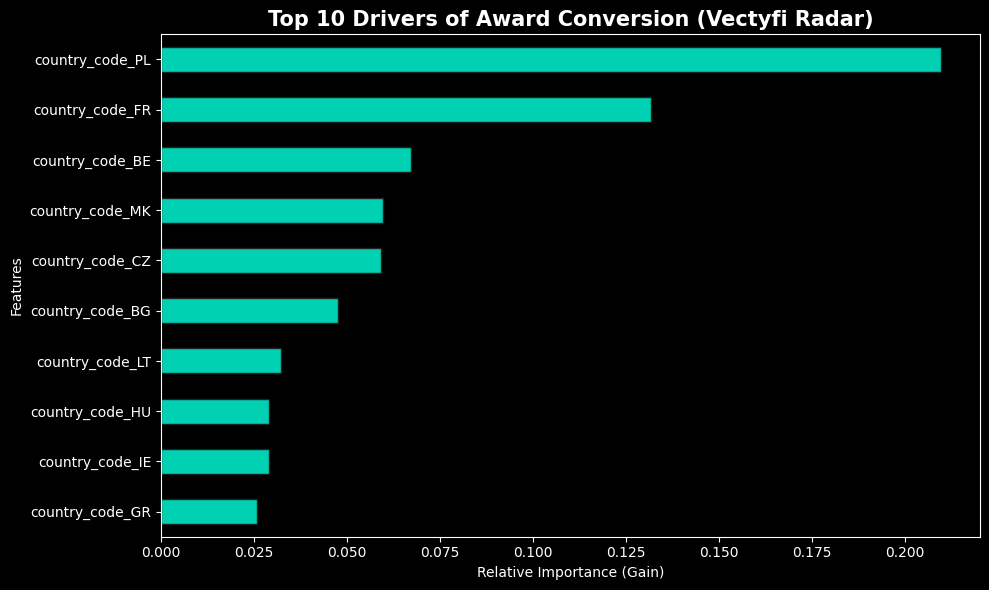

In [10]:
# Cell 7: Evaluation & Insights
# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 1. ROC-AUC Score
auc_score = roc_auc_score(y_test, y_prob)
print("\n" + "="*30)
print(f"🏆 ROC-AUC Score: {auc_score:.4f}")
print("="*30)

# 2. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 3. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Not Awarded', 'Awarded']))

# 4. Feature Importance Plot
fig, ax = plt.subplots(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_10 = importances.sort_values(ascending=True).tail(10)

# Teal/Emerald colors for high-end styling
top_10.plot(kind='barh', ax=ax, color='#00d1b2', edgecolor='#202020')

ax.set_title('Top 10 Drivers of Award Conversion (Vectyfi Radar)', fontsize=15, fontweight='bold', color='white')
ax.set_xlabel('Relative Importance (Gain)', color='white')
ax.set_ylabel('Features', color='white')
plt.tight_layout()

print("✅ Evaluation complete. Displaying Visuals:")
plt.show()